# Question 1. BWT Encoding [20 pts]
In the language of your choice, implement a BWT encoder and encode the string below. Faster (Linear time) methods exist for computing the BWT, although for this assignment you can use the simple method based on standard sorting techniques. Your solution does not need to be an optimal algorithm and can use O(n^2) space and O(n^2 lg n) time.

Here is the recommended pseudo code (make sure to submit your code as well as the encoded string):
```bash
computeBWT(string s)
  ## add the magic end-of-string character
  s = s + "$"
 
  ## build up the BWM from the cyclic permutations
  ## note the ith cyclic permutation is just "s[i..n] + s[0..i]"
  rows = []
  for (i = 0; i < length(s); i++)
    rows.append(cyclic_permutation(s, i))

  ## just use the builtin sort command to sort the cyclic permutations
  sort(rows)

  ## now extract the last column
  bwt = ""
  for (i = 0; i < length(s); i++)
    bwt += substr(rows[i], length(s), 1)
  return bwt
```
String to encode:  

```I_am_fully_convinced_that_species_are_not_immutable;_but_that_those_belonging_to_what_are_called_the_same_genera_are_lineal_descendants_of_some_other_and_generally_extinct_species,_in_the_same_manner_as_the_acknowledged_varieties_of_any_one_species_are_the_descendants_of_that_species._Furthermore,_I_am_convinced_that_natural_selection_has_been_the_most_important,_but_not_the_exclusive,_means_of_modification.```

In [ ]:
# implement the BWT encoding
import sys

import test


def bwt_encode(input_string):
    # Append the end-of-string character
    input_string += "$"
    n = len(input_string)

    # Generate all rotations of the input string
    rotations = [input_string[i:] + input_string[:i] for i in range(n)]

    # Sort the rotations lexicographically
    sorted_rotations = sorted(rotations)

    # Construct the BWT by taking the last character of each sorted rotation
    bwt_result = "".join(rotation[-1] for rotation in sorted_rotations)

    return bwt_result


# test the function with an example
test_string = "I_am_fully_convinced_that_species_are_not_immutable;_but_that_those_belonging_to_what_are_called_the_same_genera_are_lineal_descendants_of_some_other_and_generally_extinct_species,_in_the_same_manner_as_the_acknowledged_varieties_of_any_one_species_are_the_descendants_of_that_species._Furthermore,_I_am_convinced_that_natural_selection_has_been_the_most_important,_but_not_the_exclusive,_means_of_modification."
print(bwt_encode(test_string))

.etsense__$.,eIIrftassrse,;emyleeymedntt,ee,fetetssssyeeelftttedfdtsetndntgdort_ercr__ss_metdd_____vh_hhhhhcn__a___innsseeeeax__neneeeenn__eorvlhsrhhmrmhrmhhnrnmpppplcclglbsbeccgghnnnhiiiiiddi__ooooi_nd__n_wtttttttttttttfcccctrd___vvtlgttscaabelw_auaecllaa_aao_i_r_imooei_iiiaeeoineeioa__kaaaaooatm____sii_lccmphmnn_nssssmeeeueoaaaaaeoueeeeaentta__eeo_u_____onaosaucaauoaur__________or_exac_nnaftFlbbm_inn_oeelln


# Question 2. BWT Decoder [20 pts]

In the language of your choice, implement a BWT decoder and decode the string below. 

One of the essential properties of the BWT is that it can be decoded back into the source text without any other additional information. This is accomplished by iteratively applying the Last-First property starting with the first character of the BWT until reaching the end of string character `'$'`. The Last-First property states there is an equivalence between the ith occurrence of a character in the first column and the ith occurrence of that character in the last column. This equivalence can be evaluated by counting how many occurrences of a character are present in the BWT string (the last column of the BWM) or by counting characters in the first column (which you will have to determine from the BWT itself). Again, faster methods exist (the FM-index) to determine the rank of each character but you can just count it explicitly here.

The pseudocode for decoding the string is as follows:

```bash
decodeBWT(String bwt) 
  firstCol = makeFirstColumn(bwt) # sort the characters of bwt
  text = ""
  
  ## By construction, '$' always starts the zeroth row
  row = 0;
  while (bwt.charAt(row) != '$')
      text.append(bwt.charAt(row));
      row = applyLF(firstCol, bwt.charAt(row), rank(bwt, row)); # apply the Last-First property
  
  return reverse(text)
```

String to decode:
```
.uspe_gexr_______$..,e.orrs,sdddeedkdsuoden-tf,tyewtktttt,sewteb_ce__ww__h_PPsm_u_naseueeennnrrlmwwhWcrskkmHwhttv_no_nnwttzKt_l_ocoo_be___aaaooaAakiiooett_oooi_sslllfyyD__uouuueceetenagan___rru_aasanIiatt__c__saacooor_ootjeae______ir__a
```

Hint: use your sourcecode from Q1 to debug Q2. Also start with simple strings like GATTACA or your own name.

In [ ]:
# implement the BWT decoding based on the pseudocode provided
def bwt_decode(bwt):
    n = len(bwt)

    # Create the first column by sorting the characters of bwt with $ at the start
    first_col = sorted(bwt)  # Ensure $ is at the start
    assert first_col[0] == "$"

    # Create a mapping from each character in bwt to its position in first_col
    char_to_positions = {}
    for i, char in enumerate(first_col):
        if char not in char_to_positions:
            char_to_positions[char] = []
        char_to_positions[char].append(i)

    # Create a rank array to keep track of the occurrence of each character up to each position
    rank = {}
    for i, char in enumerate(bwt):
        if char not in rank:
            rank[char] = 0
        rank[char] += 1

    # Create a next array to map each position in bwt to its corresponding position in first_col
    next_array = [0] * n
    count = {}
    for i, char in enumerate(bwt):
        if char not in count:
            count[char] = 0
        next_array[i] = char_to_positions[char][count[char]]
        count[char] += 1

    # Decode the original string using the Last-First property
    text = []
    row = bwt.index("$")  # Start from the row with '$'
    for _ in range(n - 1):  # Exclude the '$' character
        text.append(bwt[row])
        row = next_array[row]

    return "".join(reversed(text))


# test the function with the provided BWT string
bwt_string = ".uspe_gexr_______$..,e.orrs,sdddeedkdsuoden-tf,tyewtktttt,sewteb_ce__ww__h_PPsm_u_naseueeennnrrlmwwhWcrskkmHwhttv_no_nnwttzKt_l_ocoo_be___aaaooaAakiiooett_oooi_sslllfyyD__uouuueceetenagan___rru_aasanIiatt__c__saacooor_ootjeae______ir__a"
print(bwt_decode(bwt_string))

e_went_up,_saw_the_structure,_we_came_back_to_Kings_and_looked_at_our_Pattersons,_and_every_section_of_our_Pattersons_we_looked_at_screamed_at_you,_Double_Helix._And_it_was_just_there._-_once_you_knew_what_to_look_for._It_was_amazing.$


# Question 3. Binomial Distribution [20 pts]

## 3a. 
For coverage n = 10 to 200, calculate the maximum number of minor allele reads (round down) that would make your one-sided binomial test reject the null hypothesis p=0.5 at 0.05 significance. Plot coverage on the x-axis and (number of reads)/(coverage) on the y-axis. Note this is the minimum number of reads that are necessary to believe we might have a heterozygous variant on the second haplotype rather than just mere sequencing error.


In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binom


# Compute critical k using binom.cdf
def left_tail_critical_k(n, alpha=0.05, p=0.5):
    # Find the largest k such that CDF(k) <= alpha
    cdfs = binom.cdf(np.arange(0, n + 1), n, p)
    valid = np.where(cdfs <= alpha)[0]
    return valid[-1] if len(valid) > 0 else 0


rows2 = []
for n in range(10, 201):
    k = left_tail_critical_k(n, alpha=0.05, p=0.5)
    frac = k / n
    rows2.append({"coverage_n": n, "k_critical": k, "k_over_n": frac})

df2 = pd.DataFrame(rows2)

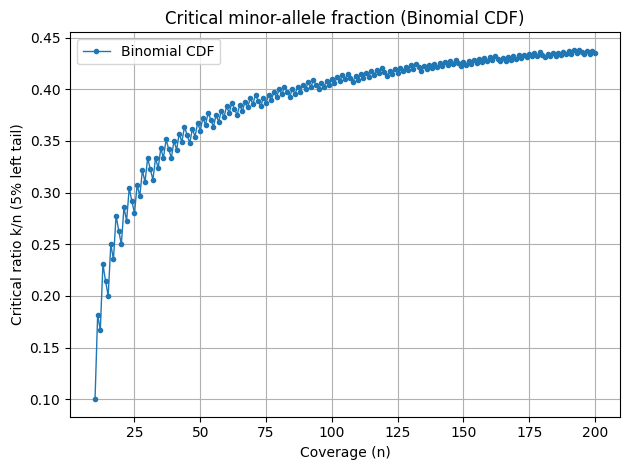

In [56]:
# Plot
plt.figure()
plt.plot(
    df2["coverage_n"],
    df2["k_over_n"],
    marker=".",
    linewidth=1,
    label="Binomial CDF",
)
plt.xlabel("Coverage (n)")
plt.ylabel("Critical ratio k/n (5% left tail)")
plt.title("Critical minor-allele fraction (Binomial CDF)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## 3b. 
What asymptote does the plot seem to approach? Why is this?

A. The plot seems to approach an asymtote of 0.5. This is because as n increases, the binomial distribution approaches a normal distribution centered at np with standard deviation sqrt(np(1-p)). For p=0.5, this means the distribution is centered at n/2 with standard deviation sqrt(n)/2. As n increases, the standard deviation increases more slowly than the mean, so the distribution becomes more concentrated around the mean. Therefore, the critical value k that satisfies P(X <= k) = 0.05 will be closer and closer to n/2 as n increases, leading to k/n approaching 0.5.

# Question 4. Identifying a Specific Variant [20 pts]

*Three friends, Ezra, Sabine, and Zeb go out to lunch together and, in discussing the menu, all realize that they all have a specific culinary preference. They believe the cause of this preference to be genetic. Can you identify what SNP causes this preference and what the preference is?*

Download the read set from here: [https://github.com/schatzlab/appliedgenomics2025/tree/main/assignments/assignment3/input_files](https://github.com/schatzlab/appliedgenomics2025/tree/main/assignments/assignment3/input_files)

For this question, you may find this tutorial helpful: [https://hbctraining.github.io/In-depth-NGS-Data-Analysis-Course/sessionVI/lessons/02_variant-calling.html](https://hbctraining.github.io/In-depth-NGS-Data-Analysis-Course/sessionVI/lessons/02_variant-calling.html)

To answer the following questions, you will need to run several alignment and variant calling tools. You can run these on the command line or embed them into a jupyter notebook, but make sure to record the exact commands you used.

- 4a. You are able to narrow down the SNP to a specific region in chromosome 11. Using bowtie2, align their FASTQ files to the provided reference file. How many reads does each file have and how many are successfully mapped? [Hint: Use `samtools flagstat`.] 


In [49]:
%%bash
set -euo pipefail

# Reference genome 
DIR="input_files"
cd "$DIR"
REF="ref.fa.gz"

# Index the reference if not already indexed
if [ ! -e "${REF}.bwt" ]; then
    echo "Indexing reference genome..."
    bwa index "$REF"
fi

# Loop over all FASTQ files in current directory
for fq in *.fastq.gz; do
    # Extract sample name by removing .fastq.gz extension
    sample=$(basename "$fq" .fastq.gz)

    echo "Processing $sample ..."

    # Align with BWA-MEM, convert to BAM, sort, and index
    bwa mem -t 8 "$REF" "$fq" \
    | samtools view -bS - \
    | samtools sort -o "${sample}.sorted.bam"

    samtools index "${sample}.sorted.bam"

    echo "Finished $sample → ${sample}.sorted.bam"
done

echo "All alignments complete!"

Processing ezra.read1 ...


[M::bwa_idx_load_from_disk] read 0 ALT contigs
[M::process] read 451128 sequences (31578960 bp)...

Usage:   samtools sort [options] <in.bam> <out.prefix>

Options: -n        sort by read name
         -f        use <out.prefix> as full file name instead of prefix
         -o        final output to stdout
         -l INT    compression level, from 0 to 9 [-1]
         -@ INT    number of sorting and compression threads [1]
         -m INT    max memory per thread; suffix K/M/G recognized [768M]

[M::mem_process_seqs] Processed 451128 reads in 7.870 CPU sec, 0.988 real sec
[samopen] SAM header is present: 1 sequences.
[fputs] Broken pipe


CalledProcessError: Command 'b'set -euo pipefail\n\n# Reference genome \nDIR="input_files"\ncd "$DIR"\nREF="ref.fa.gz"\n\n# Index the reference if not already indexed\nif [ ! -e "${REF}.bwt" ]; then\n    echo "Indexing reference genome..."\n    bwa index "$REF"\nfi\n\n# Loop over all FASTQ files in current directory\nfor fq in *.fastq.gz; do\n    # Extract sample name by removing .fastq.gz extension\n    sample=$(basename "$fq" .fastq.gz)\n\n    echo "Processing $sample ..."\n\n    # Align with BWA-MEM, convert to BAM, sort, and index\n    bwa mem -t 8 "$REF" "$fq" \\\n    | samtools view -bS - \\\n    | samtools sort -o "${sample}.sorted.bam"\n\n    samtools index "${sample}.sorted.bam"\n\n    echo "Finished $sample \xe2\x86\x92 ${sample}.sorted.bam"\ndone\n\necho "All alignments complete!"\n'' returned non-zero exit status 1.

In [ ]:
%%bash
DIR="input_files"
cd "$DIR"
set -euo pipefail
# Loop over all .sorted.bam files and run samtools flagstat
# Loop over all .sorted.bam files and run samtools flagstat, saving output for analysis
for bam in *.sorted.bam; do
    echo "Sample: $bam" >> flagstat_summary.txt
    samtools flagstat "$bam" >> flagstat_summary.txt
    echo "" >> flagstat_summary.txt
done
# count number of BAM files (blocks expected in flagstat_summary.txt)
n_files=$(ls -1 *.sorted.bam 2>/dev/null | wc -l)

# extract every 1st, 2nd and 8th line from each blank-line-separated block
echo "Total Reads, Mapped Reads, and Percent Properly Paired for each BAM:" 
echo ""
awk -v n="$n_files" 'BEGIN { RS=""; FS="\n" }
NR<=n {
    if (NF>=1) print $1
    if (NF>=2) print $2
    if (NF>=8) print $8
    print ""
}' flagstat_summary.txt > flagstat_selected.txt

cat flagstat_selected.txt


Total Reads, Mapped Reads, and Percent Properly Paired for each BAM:

Sample: ezra.read1.sorted.bam
451128 + 0 in total (QC-passed reads + QC-failed reads)
428611 + 0 mapped (95.01% : N/A)

Sample: ezra.read2.sorted.bam
451128 + 0 in total (QC-passed reads + QC-failed reads)
428597 + 0 mapped (95.01% : N/A)

Sample: sabine.read1.sorted.bam
451128 + 0 in total (QC-passed reads + QC-failed reads)
428485 + 0 mapped (94.98% : N/A)

Sample: sabine.read2.sorted.bam
451128 + 0 in total (QC-passed reads + QC-failed reads)
428483 + 0 mapped (94.98% : N/A)

Sample: zeb.read1.sorted.bam
451128 + 0 in total (QC-passed reads + QC-failed reads)
428282 + 0 mapped (94.94% : N/A)

Sample: zeb.read2.sorted.bam
451128 + 0 in total (QC-passed reads + QC-failed reads)
428254 + 0 mapped (94.93% : N/A)




- 4b. How many high confidence SNPs and indels does each file have? [Hint: Sort the SAM file first. Then, call variants with `freebayes`. Then filter for the variant quality to be at least 30 and normalize using `bcftools`. Summarize using `bcftools stats`.]


In [ ]:
%%bash
DIR="input_files"
cd "$DIR"
set -euo pipefail

# Usage: ./call_variants.sh [REFERENCE.fa]
# Defaults to input_files/ref.fa or input_files/ref.fa.gz if exists.
REF="ref.fa"

bams=( *.sorted.bam )

# Loop over sorted BAMs and call variants with freebayes, then filter & normalize
for bam in "${bams[@]}"; do
    sample="${bam%.sorted.bam}"
    echo "=== Processing sample: $bam ==="

    # Call variants with freebayes
    raw_vcf="${sample}.raw.vcf"
    echo "Running freebayes -> $raw_vcf"
    freebayes -f "$REF" "$bam" > "$raw_vcf"
    # freebayes -f "$REF" -s ezra.read1 "$bam" | bgzip -c > "$raw_vcfgz"

    # Filter variants by quality (QUAL >= 30)
    filt_vcf="${sample}.filtered.vcf"
    echo "Filtering (QUAL>=30) -> $filt_vcf"
    # Filter QUAL>=30 (preserve headers). Use awk to handle missing QUAL '.' safely
    bcftools view -i 'QUAL>=30' "$raw_vcf" -Oz -o "$filt_vcf"

    # Normalize (split multiallelics) and left-align indels
    norm_vcf="${sample}.norm.vcf"
    echo "Normalizing -> $norm_vcf"
    # Read possibly bgzipped filtered VCF and output an uncompressed, normalized VCF
    bcftools norm -f "$REF" "$filt_vcf" > "$norm_vcf"

    # produce basic stats
    stats="${sample}.norm.vcf.stats.txt"
    echo "Generating stats -> $stats"
    bcftools stats "$norm_vcf" > "$stats"

    # Compress and index final VCF
    gz_vcf="${norm_vcf}.gz"
    echo "Compressing and indexing -> $gz_vcf"
    bgzip -c "$norm_vcf" > "$gz_vcf"
    bcftools index "$gz_vcf"
    echo "Finished $sample"
done

echo "All samples processed."

# compare variants across samples
echo "Comparing variants across samples..."
vcf_list=( *.norm.vcf.gz )


echo "VCF files: ${vcf_list[*]}"
echo "Running bcftools isec on first three files..."
bcftools isec "${vcf_list[0]}" "${vcf_list[1]}" "${vcf_list[2]}" -p norm -n=3

=== Processing sample: ezra.read1.sorted.bam ===
Running freebayes -> ezra.read1.raw.vcf
Filtering (QUAL>=30) -> ezra.read1.filtered.vcf
Normalizing -> ezra.read1.norm.vcf


Lines   total/split/joined/realigned/mismatch_removed/dup_removed/skipped:	1370/0/0/137/0/0/0


Generating stats -> ezra.read1.norm.vcf.stats.txt
Compressing and indexing -> ezra.read1.norm.vcf.gz
Finished ezra.read1
=== Processing sample: ezra.read2.sorted.bam ===
Running freebayes -> ezra.read2.raw.vcf
Filtering (QUAL>=30) -> ezra.read2.filtered.vcf
Normalizing -> ezra.read2.norm.vcf


Lines   total/split/joined/realigned/mismatch_removed/dup_removed/skipped:	1398/0/0/146/0/0/0


Generating stats -> ezra.read2.norm.vcf.stats.txt
Compressing and indexing -> ezra.read2.norm.vcf.gz
Finished ezra.read2
=== Processing sample: sabine.read1.sorted.bam ===
Running freebayes -> sabine.read1.raw.vcf
Filtering (QUAL>=30) -> sabine.read1.filtered.vcf
Normalizing -> sabine.read1.norm.vcf


...

Generating stats -> sabine.read2.norm.vcf.stats.txt
Compressing and indexing -> sabine.read2.norm.vcf.gz
Finished sabine.read2
=== Processing sample: zeb.read1.sorted.bam ===
Running freebayes -> zeb.read1.raw.vcf
Filtering (QUAL>=30) -> zeb.read1.filtered.vcf
Normalizing -> zeb.read1.norm.vcf


Lines   total/split/joined/realigned/mismatch_removed/dup_removed/skipped:	1386/0/0/146/0/0/0


Generating stats -> zeb.read1.norm.vcf.stats.txt
Compressing and indexing -> zeb.read1.norm.vcf.gz
Finished zeb.read1
=== Processing sample: zeb.read2.sorted.bam ===
Running freebayes -> zeb.read2.raw.vcf
Filtering (QUAL>=30) -> zeb.read2.filtered.vcf
Normalizing -> zeb.read2.norm.vcf


Lines   total/split/joined/realigned/mismatch_removed/dup_removed/skipped:	1443/0/0/143/0/0/0


Generating stats -> zeb.read2.norm.vcf.stats.txt
Compressing and indexing -> zeb.read2.norm.vcf.gz
Finished zeb.read2
All samples processed.
Comparing variants across samples...
VCF files: ezra.read1.norm.vcf.gz ezra.read2.norm.vcf.gz sabine.read1.norm.vcf.gz sabine.read2.norm.vcf.gz zeb.read1.norm.vcf.gz zeb.read2.norm.vcf.gz
Running bcftools isec on first three files...


In [ ]:
from pathlib import Path
import os

files = [f for f in os.listdir("input_files") if f.endswith("norm.vcf.stats.txt")]
# print(files)

for path in sorted(Path("input_files").rglob("*norm.vcf.stats.txt")):
    snps = indels = None
    with path.open() as fh:
        for line in fh:
            parts = line.strip().split("\t")
            if len(parts) < 4:
                continue
            if parts[0] == "SN" and parts[2] == "number of SNPs:":
                snps = int(parts[3])
            if parts[0] == "SN" and parts[2] == "number of indels:":
                indels = int(parts[3])
    print(f"{path.name}\t{snps}\t{indels}")

ezra.read1.norm.vcf.stats.txt	1260	109
ezra.read2.norm.vcf.stats.txt	1278	118
sabine.read1.norm.vcf.stats.txt	1298	109
sabine.read2.norm.vcf.stats.txt	1268	116
zeb.read1.norm.vcf.stats.txt	1273	108
zeb.read2.norm.vcf.stats.txt	1329	110



- 4c. You now know which SNPs and indels each friend has. However, you want to know which variant they all share. How many variants are shared between all three friends? [Hint: Use `bcftools isec` after filtering and normalizing the variants.]


In [ ]:
%%bash
DIR="input_files"
echo "Variants in intersection of all three samples:"
grep -v '^#' "$DIR/norm/0000.vcf"
grep -v '^#' "$DIR/norm/0001.vcf"
grep -v '^#' "$DIR/norm/0002.vcf"
grep -v '^#' "$DIR/norm/sites.txt"

Variants in intersection of all three samples:
chr11:5868417-7868417	1000000	.	C	A	185.853	.	AB=0;ABP=0;AC=2;AF=1;AN=2;AO=11;CIGAR=1X;DP=11;DPB=11;DPRA=0;EPP=4.78696;EPPR=0;GTI=0;LEN=1;MEANALT=1;MQM=60;MQMR=0;NS=1;NUMALT=1;ODDS=19.8544;PAIRED=0;PAIREDR=0;PAO=0;PQA=0;PQR=0;PRO=0;QA=229;QR=0;RO=0;RPL=7;RPP=4.78696;RPPR=0;RPR=4;RUN=1;SAF=5;SAP=3.20771;SAR=6;SRF=0;SRP=0;SRR=0;TYPE=snp	GT:DP:AD:RO:QR:AO:QA:GL	1/1:11:0,11:0:0:11:229:-20.8176,-3.31133,0
chr11:5868417-7868417	1000000	.	C	A	366.412	.	AB=0;ABP=0;AC=2;AF=1;AN=2;AO=22;CIGAR=1X;DP=22;DPB=22;DPRA=0;EPP=9.32731;EPPR=0;GTI=0;LEN=1;MEANALT=1;MQM=60;MQMR=0;NS=1;NUMALT=1;ODDS=35.1036;PAIRED=0;PAIREDR=0;PAO=0;PQA=0;PQR=0;PRO=0;QA=438;QR=0;RO=0;RPL=11;RPP=3.0103;RPPR=0;RPR=11;RUN=1;SAF=12;SAP=3.40511;SAR=10;SRF=0;SRP=0;SRR=0;TYPE=snp	GT:DP:AD:RO:QR:AO:QA:GL	1/1:22:0,22:0:0:22:438:-39.6182,-6.62266,0
chr11:5868417-7868417	1000000	.	C	A	192.152	.	AB=0;ABP=0;AC=2;AF=1;AN=2;AO=12;CIGAR=1X;DP=12;DPB=12;DPRA=0;EPP=14.5915;EPPR=0;GTI=0;LEN=1;MEAN

It appears that all three friends share a SNP at chr11:5868417-7868417. 


- 4d. Between the variants shared between all three friends, which is likeliest to cause a phenotype of interest? [Hint: The variant should be homozygous in all 3 samples and will be in a gene that has a function related to taste. You can search for variants at a certain chromosome and position at https://genome.ucsc.edu/cgi-bin/hgTracks?db=hg38. Remember, the position in the intersected VCF is the position within the region we're looking at, so you will have to find the starting location of the region by shifting over by 5868417! Use `bcftools view -i 'GT="1/1"' PREFIX.vcf` to filter for the correct genotype.]


Variant at genomic coordinate chr11:6868417 (5868417 + 1000000) lands inside GENCODE gene OR10A2 (ENST00000641461.1) from GENCODE V48 according to the UCSC hg38 annotation.


- 4e. What is the phenotype? [Hint: Search the name of the gene associated with the variant you found in 4d.]

On OR10A2:  
Olfactory receptors interact with odorant molecules in the nose, to initiate a neuronal response that triggers the perception of a smell. The olfactory receptor proteins are members of a large family of G-protein-coupled receptors (GPCR) arising from single coding-exon genes. Olfactory receptors share a 7-transmembrane domain structure with many neurotransmitter and hormone receptors and are responsible for the recognition and G protein-mediated transduction of odorant signals. The olfactory receptor gene family is the largest in the genome. [provided by RefSeq, Jul 2008]

Based on this information, it is likely that the SNP affects the friends' ability to perceive certain smells, which in turn influences their culinary preferences.